# Антифрод ML-пайплайн 

In [20]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
%matplotlib inline
from pathlib import Path

from antifraud_pipeline import (
    P,
    init_notebook,
    stage_01_load_and_profile,
    stage_02_eda_plots,
    stage_03_feature_engineering,
    stage_04_prepare_split,
    stage_05_rules,
    stage_06_train_models,
    stage_07_compare_plots,
    stage_08_neural,
    stage_09_ensemble,
    stage_10_shap,
    stage_11_drift,
    stage_12_business,
    stage_13_calibration,
    stage_14_retraining,
    stage_15_combined,
    stage_16_report,
    run_all_stages,
)

init_notebook(Path.cwd())


PROJECT_ROOT: /Users/bolotnikovali/ИПС
DATA_PATH: /Users/bolotnikovali/ИПС/data/df_split_model_RF_new_features.csv
OUTPUT_DIR: /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline


In [22]:
stage_01_load_and_profile()

РАЗДЕЛ 1. ЗАГРУЗКА И ПЕРВИЧНЫЙ АНАЛИЗ
  Отброшено лишних колонок из CSV: 11

Размер (только колонки как в оригинальном ноутбуке + метаданные): 4215398 × 50

fraud_flg:
fraud_flg
0.0    21678
1.0     1769
Name: count, dtype: int64

Доля fraud: 7.5447%, соотношение 1:12

Типы (только признаки модели, 44 полей):
float64    26
int64      18
Name: count, dtype: int64

Пропуски по признакам модели (топ-20):
                                    count  percent
password_age                       713805    16.93
loan_2d_base_limit                 381185     9.04
loan_24h_base_limit                381185     9.04
loan_1h_base_limit                 381185     9.04
puid_orders_1h_without_refunds     381185     9.04
puid_orders_24h_without_refunds    381185     9.04
puid_orders_2d_without_refunds     381185     9.04
puid_days_since_login_id_creation  187008     4.44
glue_size                          127737     3.03
glue_ead                           127737     3.03
puid_age                          

## 2. EDA — графики


РАЗДЕЛ 2. EDA — графики


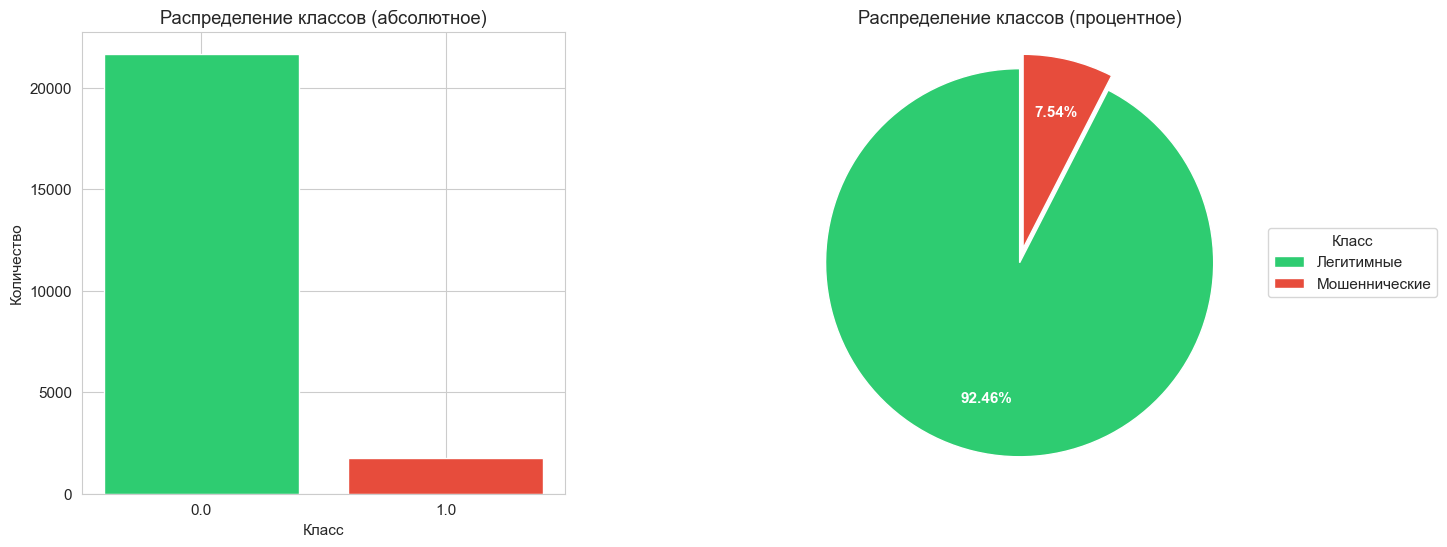

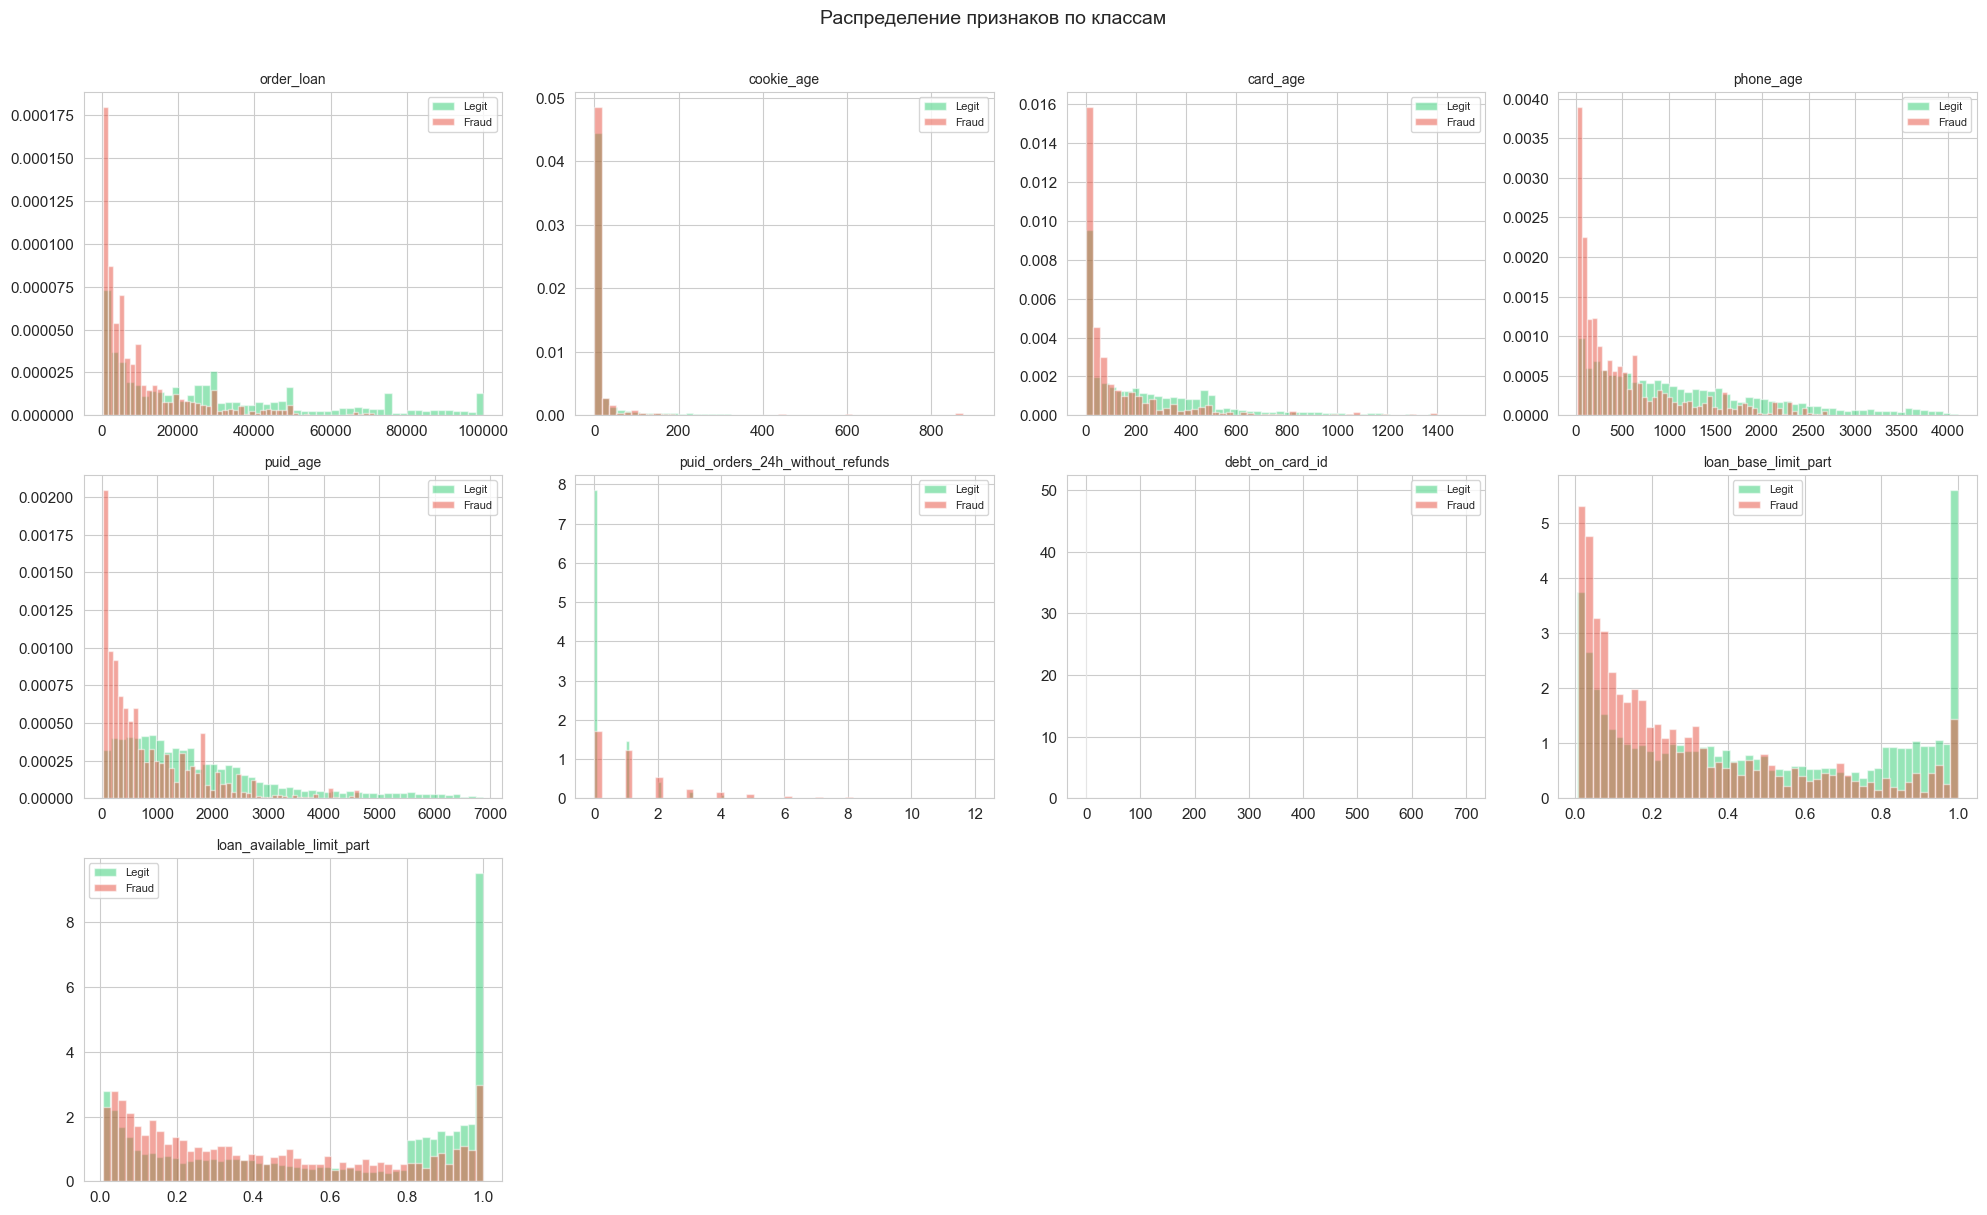

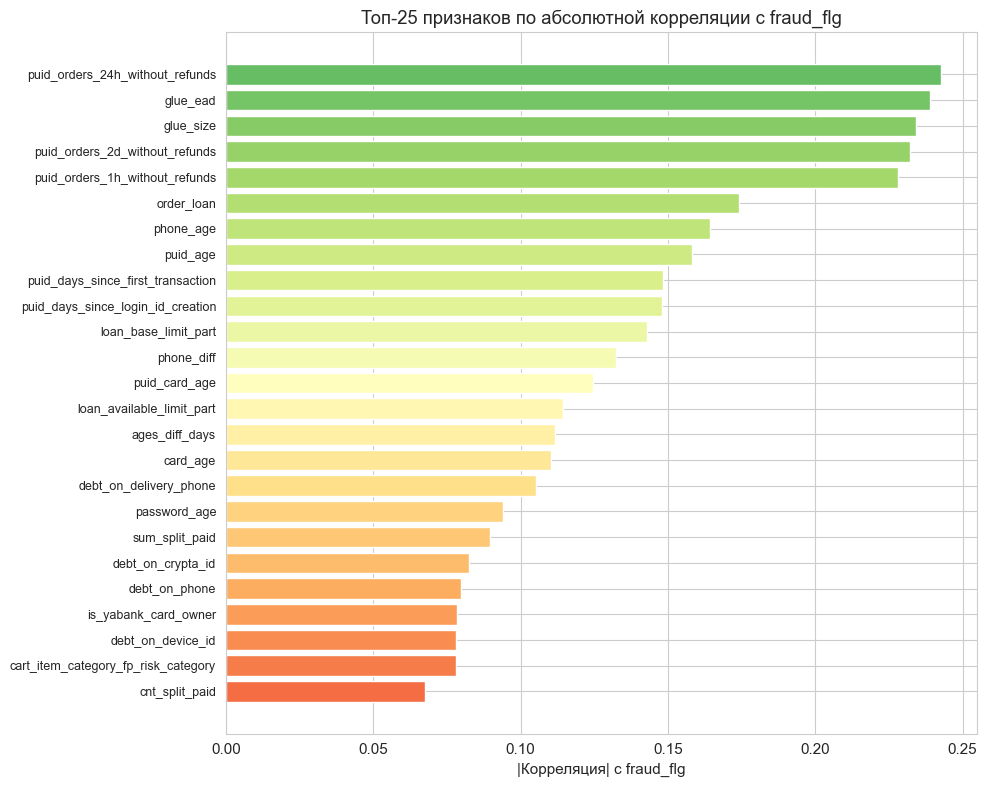


Топ-15 по |corr| с fraud_flg:
puid_orders_24h_without_refunds      0.2428
glue_ead                             0.2390
glue_size                            0.2344
puid_orders_2d_without_refunds       0.2322
puid_orders_1h_without_refunds       0.2280
order_loan                           0.1743
phone_age                            0.1643
puid_age                             0.1582
puid_days_since_first_transaction    0.1484
puid_days_since_login_id_creation    0.1482
loan_base_limit_part                 0.1428
phone_diff                           0.1324
puid_card_age                        0.1245
loan_available_limit_part            0.1143
ages_diff_days                       0.1117
Name: fraud_flg, dtype: float64


In [23]:
stage_02_eda_plots()

## 3. Инженерия признаков

In [24]:
stage_03_feature_engineering()


РАЗДЕЛ 3. ИНЖЕНЕРИЯ ПРИЗНАКОВ
  Парсинг временных признаков...
  Создание отношений (ratio features)...
  Создание возрастных признаков...
  Создание velocity-признаков...
  Создание флагов аномалий...

  Всего создано новых признаков: 32

Размер после FE: (4215398, 83)


## 4. Сплит и подготовка матриц

In [25]:
stage_04_prepare_split()


РАЗДЕЛ 4. ПОДГОТОВКА / СПЛИТ
  Удалено строк без целевой переменной (fraud_flg): 4191951
  Идентификация столбцов...
  Числовых признаков (allowlist): 44
  Категориальных признаков (allowlist): 0
  Всего признаков: 44
  Кодирование категориальных переменных...
  Разделение на train/val/test...
  Хронологический сплит:
    Train: 15240 (8.4186% fraud)
    Val:   3517 (6.1700% fraud)
    Test:  4690 (5.7356% fraud)
    Train period: 2025-05-15 00:06:18+00:00 — 2025-06-25 05:34:14+00:00
    Val period:   2025-06-25 05:48:33+00:00 — 2025-07-07 08:16:15+00:00
    Test period:  2025-07-07 08:23:03+00:00 — 2025-07-22 23:43:07+00:00
  Обработка пропусков...

X_train (15240, 44), fraud 8.4186%
X_val   (3517, 44), fraud 6.1700%
X_test  (4690, 44), fraud 5.7356%


## 5. Правила первого уровня

In [26]:
stage_05_rules()


РАЗДЕЛ 5. ПРАВИЛА L1
  Только 3 правила: extreme_velocity_1h, glue_size_spike, glue_ead_spike. Отбор на train [block]: precision, lift, доля срабатываний, мин. TP; доп. Fβ≥0.03 (β=2.0).
  Правило 'extreme_velocity_1h' [block] добавлено: prec=0.372, lift=4.42, fire=1.5%, TP=83, Fβ=0.0775
  Правило 'glue_size_spike' [block] добавлено: prec=0.731, lift=8.68, fire=0.5%, TP=57, Fβ=0.0547
  Правило 'glue_ead_spike' [block] добавлено: prec=0.623, lift=7.40, fire=0.5%, TP=48, Fβ=0.0461

  --- Статистика правил ---
  Всего транзакций: 4690
  Заблокировано правилами: 94
  Безопасно по правилам: 0
  Серая зона (→ ML): 4596
    Правило 'extreme_velocity_1h': blocked=71, safe=0
    Правило 'glue_size_spike': blocked=15, safe=0
    Правило 'glue_ead_spike': blocked=8, safe=0

  Precision блокировок по правилам: 0.3404
  Доля в серой зоне (ML): 98.00%


## 6. Обучение моделей


РАЗДЕЛ 6. ОБУЧЕНИЕ МОДЕЛЕЙ
  scale_pos_weight = 10.88

--- Логистическая регрессия (baseline) ---
  Оптимальный порог (val Fβ, β=2.0): 0.70, score=0.5357
  Test ROC-AUC: 0.8327 | PR-AUC: 0.3044 | Fβ: 0.4359


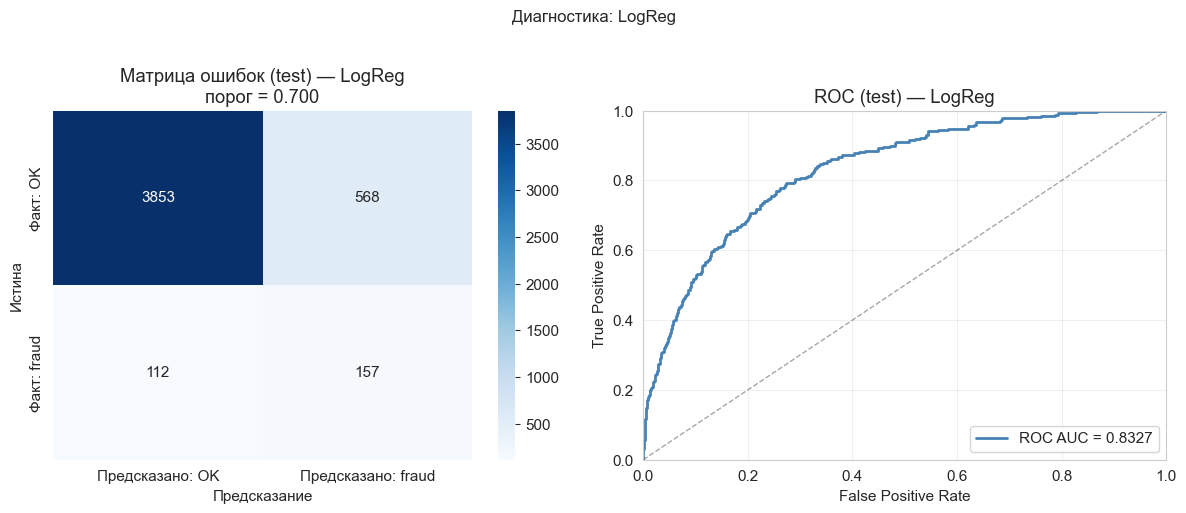

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_LogReg.png

--- XGBoost ---
  Оптимальный порог (val Fβ, β=2.0): 0.53, score=0.5933
  Test ROC-AUC: 0.8623 | PR-AUC: 0.2969 | Fβ: 0.4813


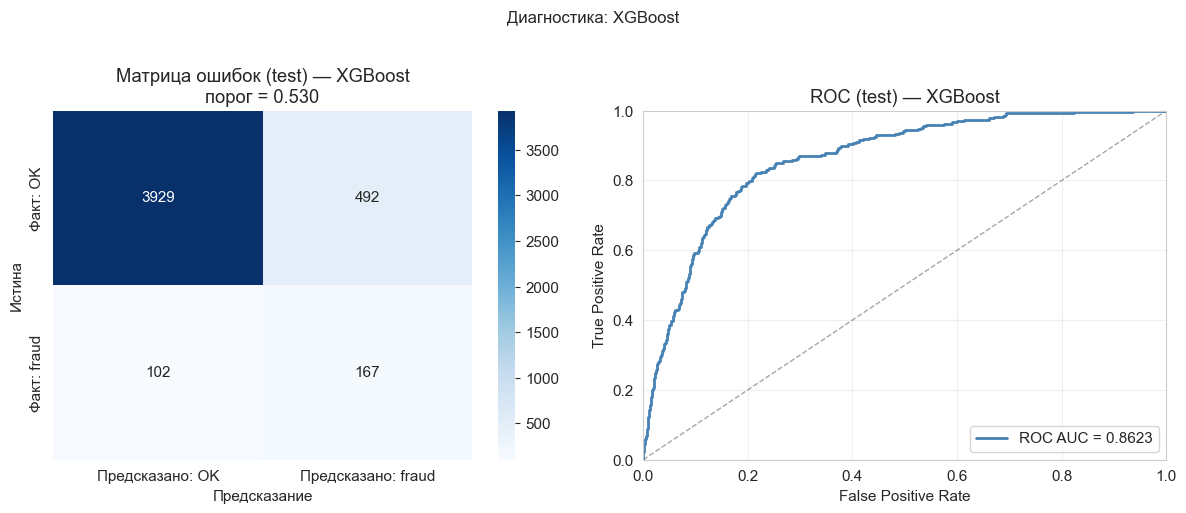

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_XGBoost.png

--- LightGBM ---
  Оптимальный порог (val Fβ, β=2.0): 0.55, score=0.5902
  Test ROC-AUC: 0.8638 | PR-AUC: 0.3127 | Fβ: 0.4478


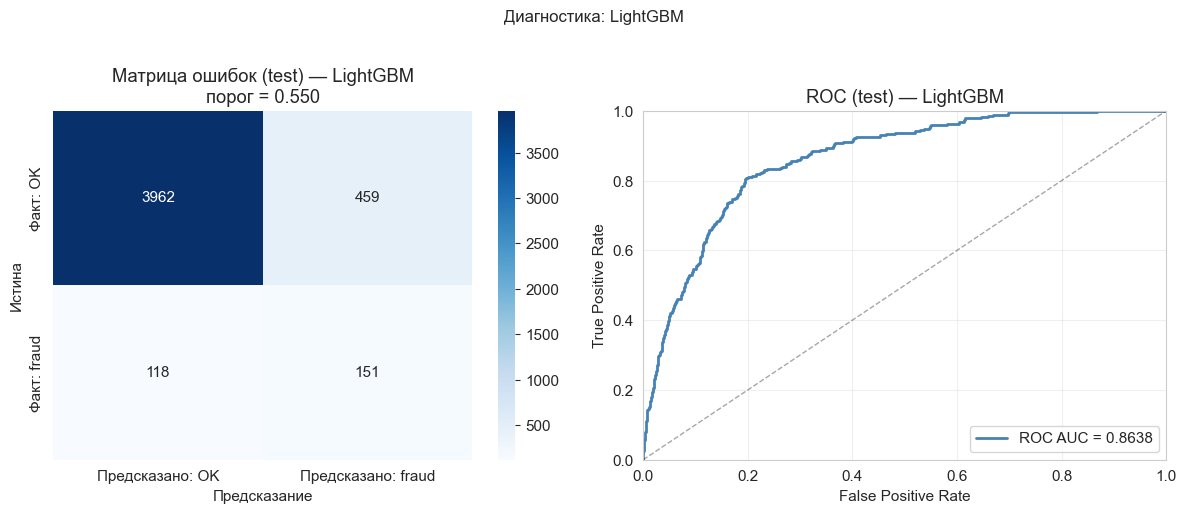

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_LightGBM.png

--- CatBoost ---
  Оптимальный порог (val Fβ, β=2.0): 0.64, score=0.5855
  Test ROC-AUC: 0.8673 | PR-AUC: 0.2813 | Fβ: 0.4603


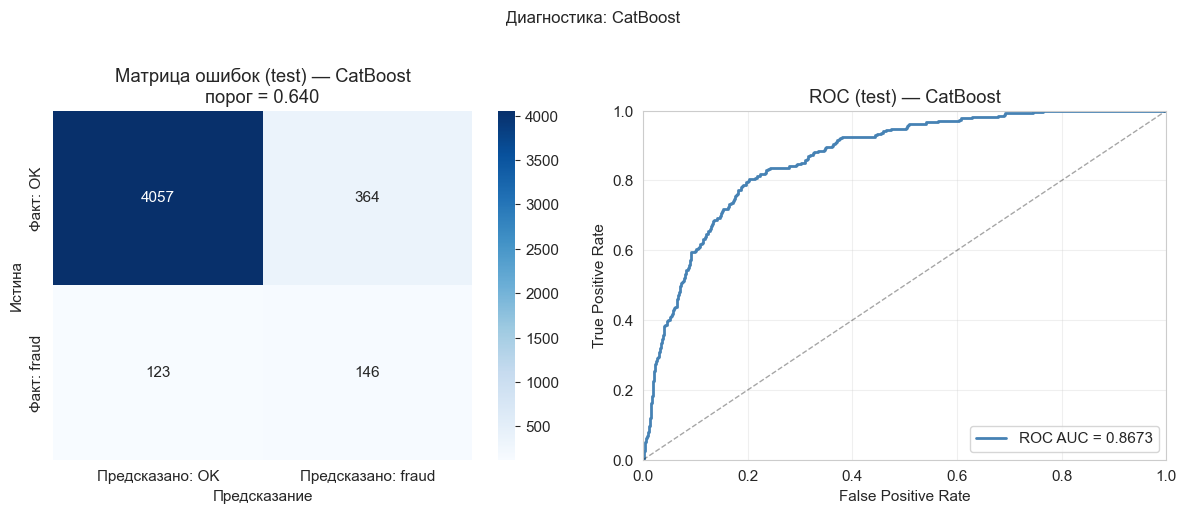

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_CatBoost.png

--- XGBoost + SMOTE ---
  SMOTE: 15240 → 27914 наблюдений
  Оптимальный порог (val Fβ, β=2.0): 0.17, score=0.5940
  Test ROC-AUC: 0.8469 | PR-AUC: 0.2849 | Fβ: 0.4594


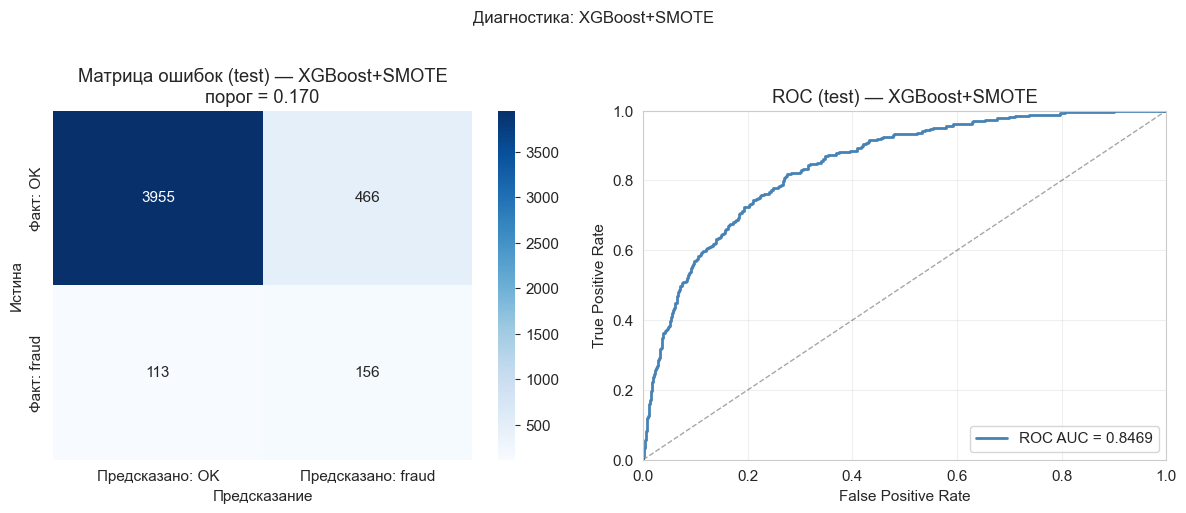

  Диагностика (CM + ROC): /Users/bolotnikovali/ИПС/outputs/antifraud_pipeline/diagnostic_cm_roc_XGBoost_SMOTE.png


In [27]:
stage_06_train_models()

## 7. Нейросети 


РАЗДЕЛ 7. СРАВНЕНИЕ

--- Сравнительная таблица метрик ---
               ROC-AUC  PR-AUC  F_beta      F1      F2  Precision  Recall     FPR
LogReg          0.8327  0.3044  0.4359  0.3159  0.4359     0.2166  0.5836  0.1285
XGBoost         0.8623  0.2969  0.4813  0.3599  0.4813     0.2534  0.6208  0.1113
LightGBM        0.8638  0.3127  0.4478  0.3436  0.4478     0.2475  0.5613  0.1038
CatBoost        0.8673  0.2813  0.4603  0.3748  0.4603     0.2863  0.5428  0.0823
XGBoost+SMOTE   0.8469  0.2849  0.4594  0.3502  0.4594     0.2508  0.5799  0.1054


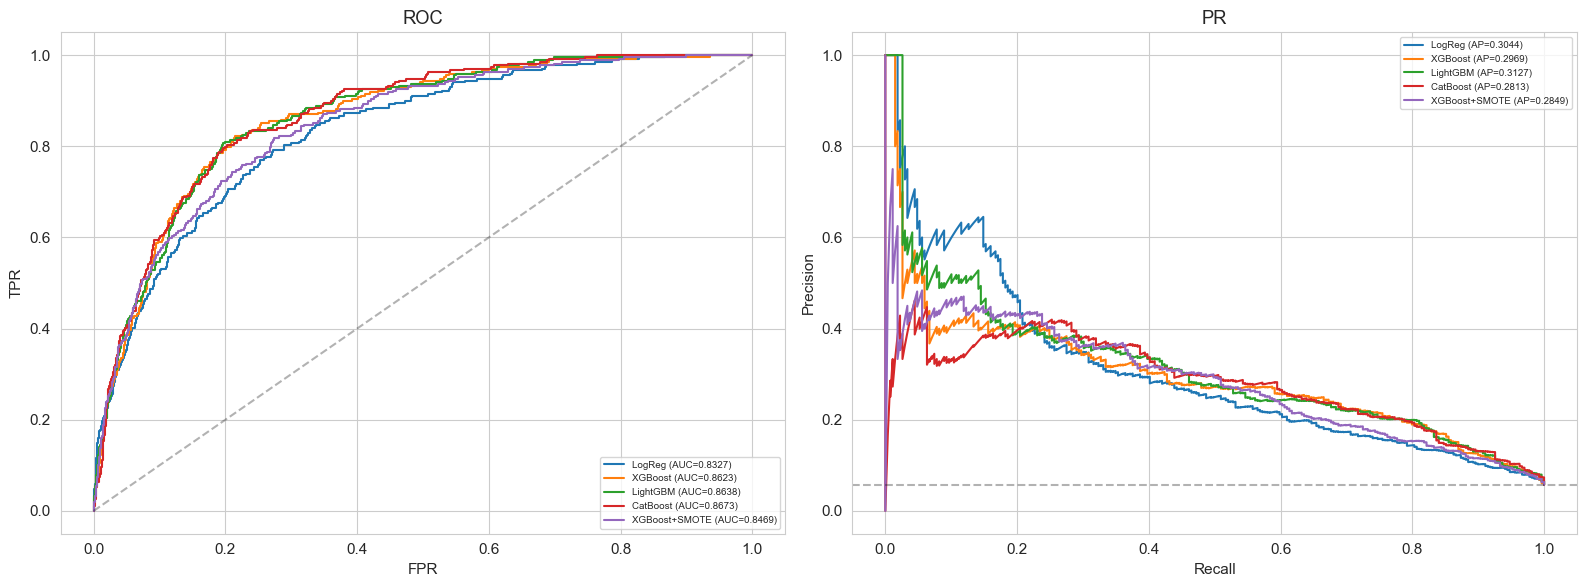

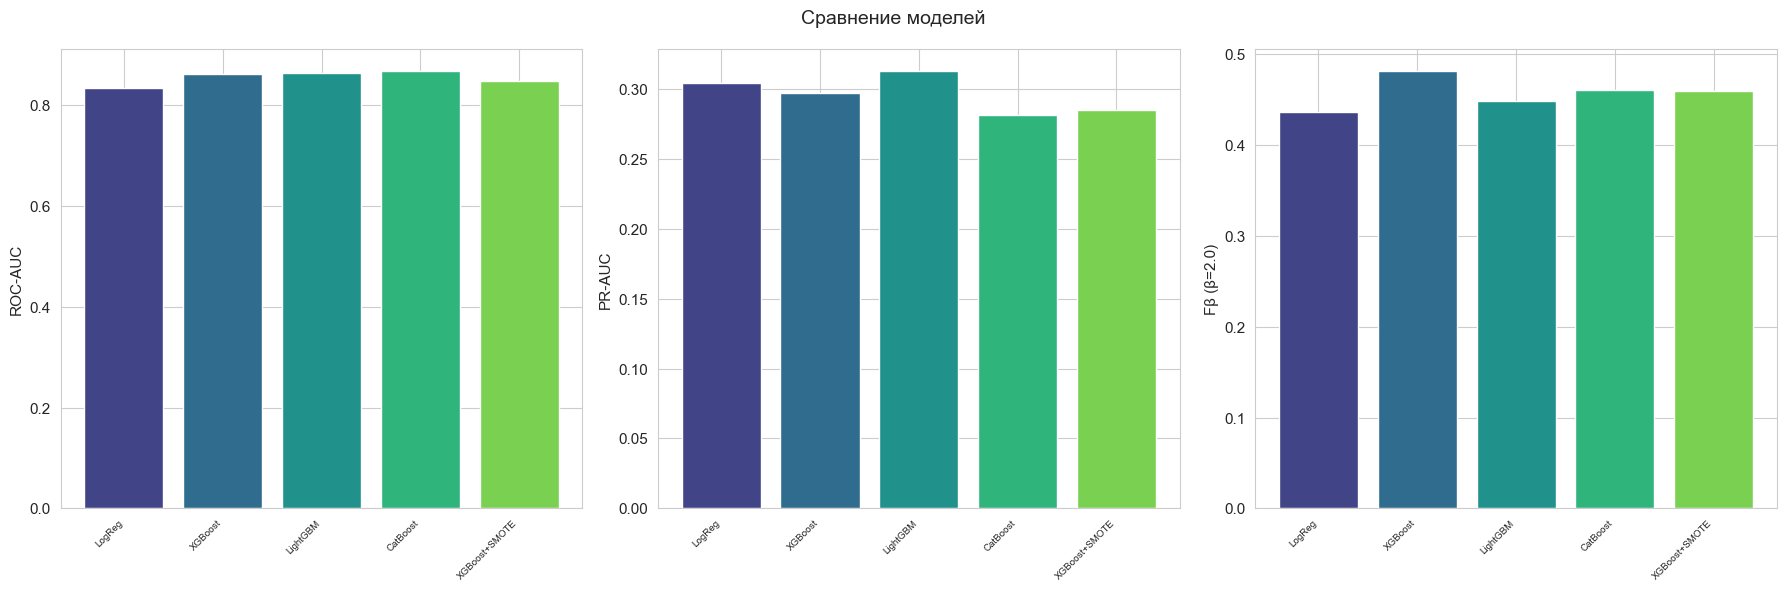

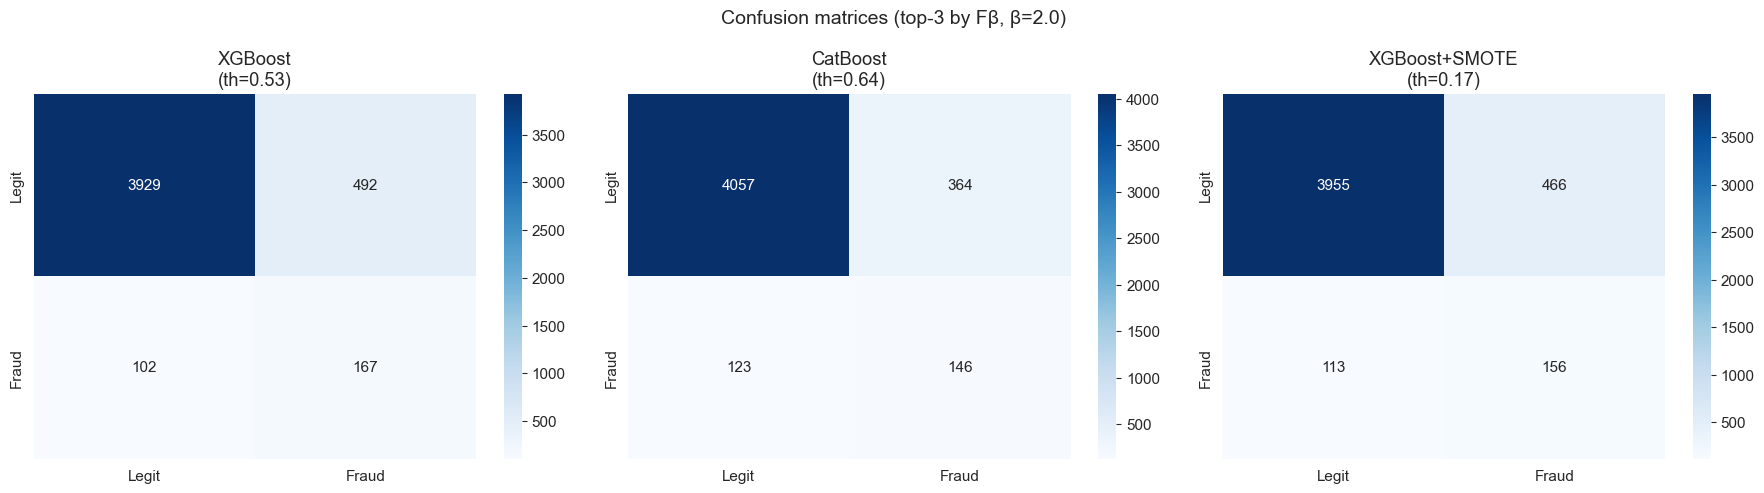

In [28]:
stage_07_compare_plots()


## 8. Ансамбли

In [29]:
# stage_08_neural()


## 9. SHAP

In [30]:
# stage_09_ensemble()


## 10. Мониторинг дрейфа


РАЗДЕЛ 10. SHAP
Модель для SHAP: XGBoost (Fβ, β=2.0=0.4813)

  Вычисление SHAP для XGBoost...
  SHAP shape: (800, 44)


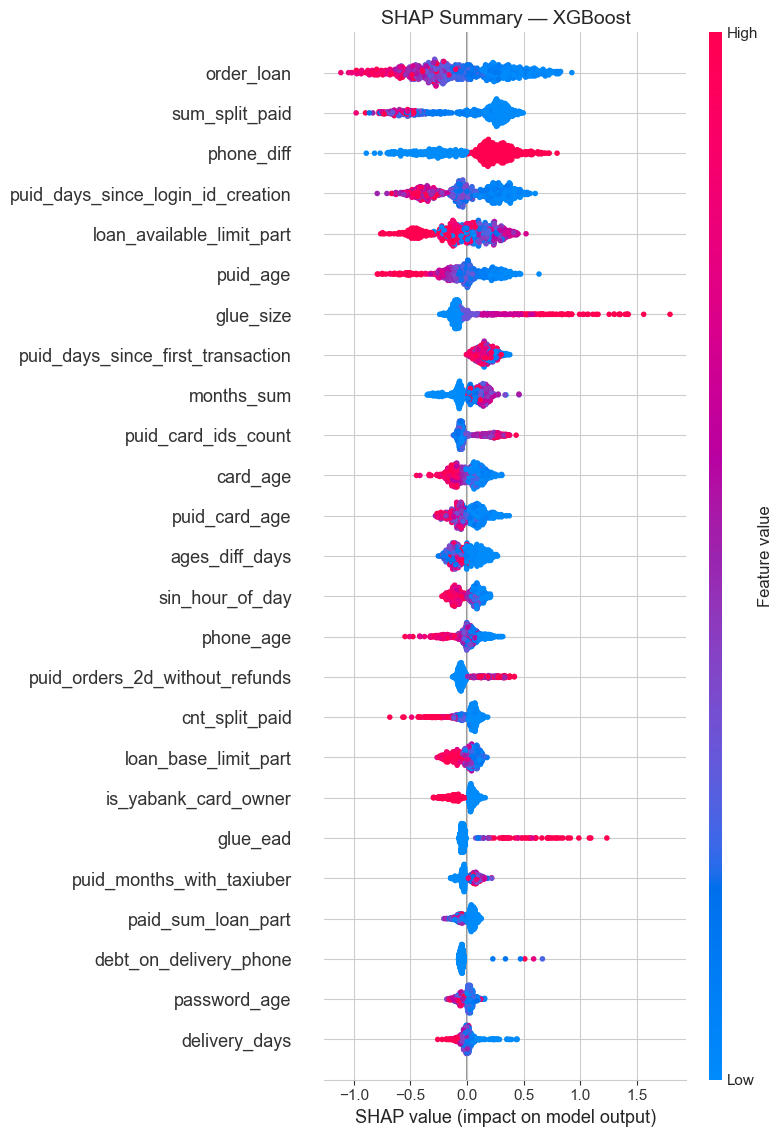

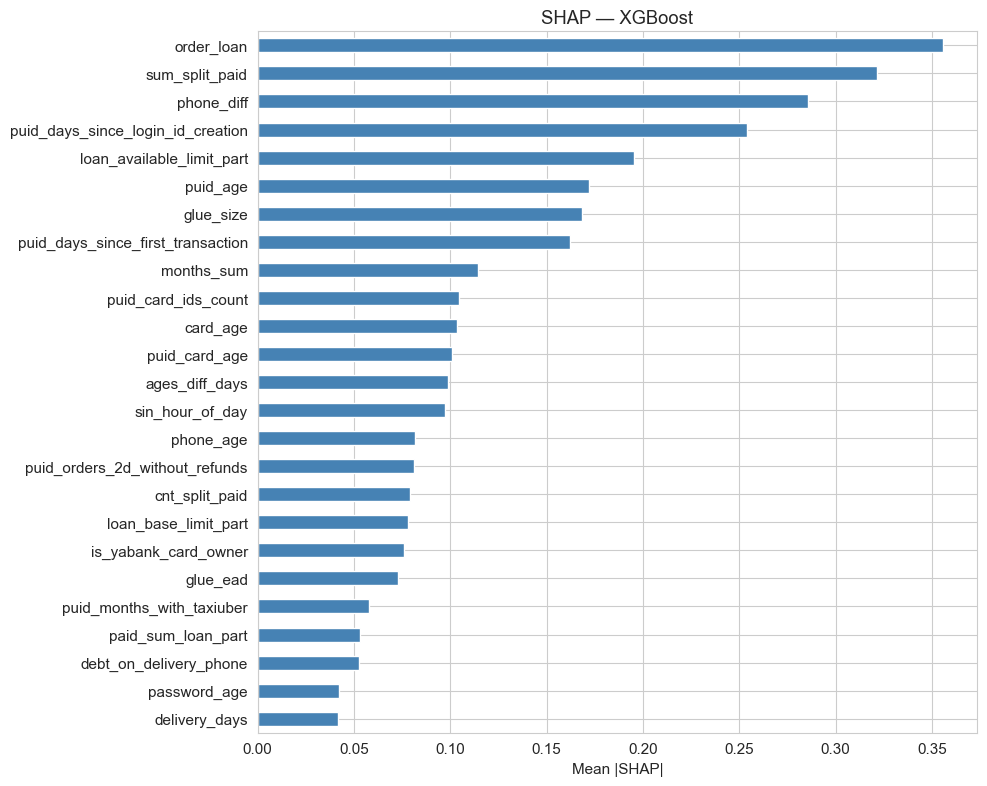

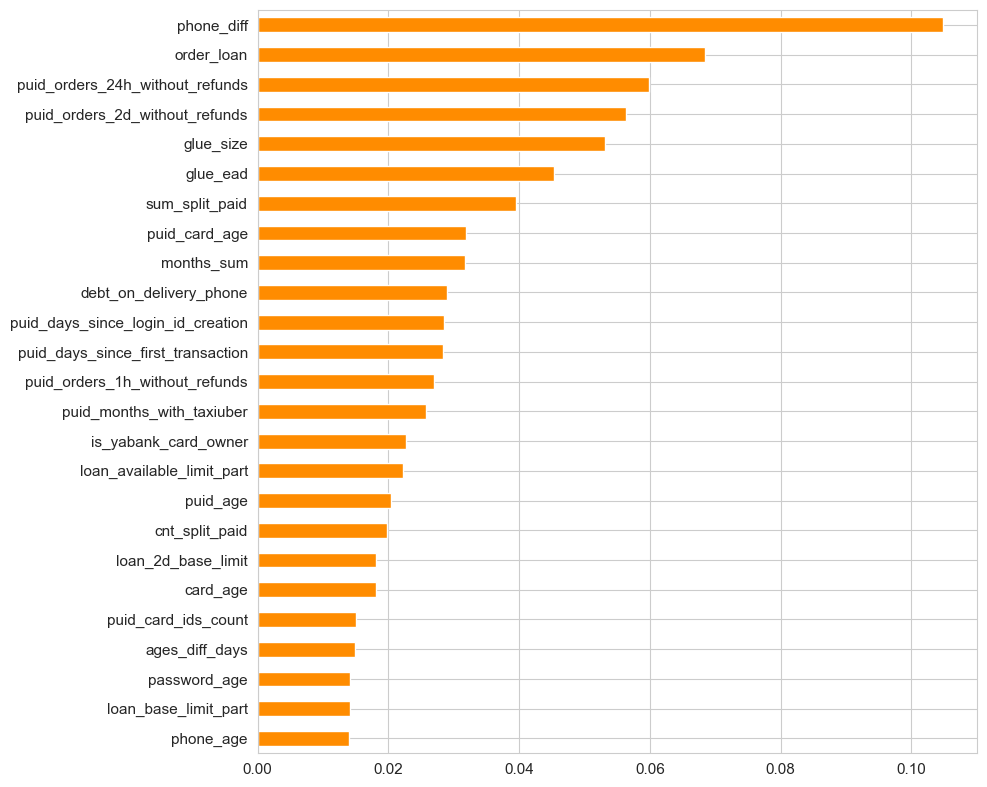

In [31]:
stage_10_shap()


## 11. Сравнение и графики



РАЗДЕЛ 11. МОНИТОРИНГ ДРЕЙФА
Дрейф признаков: 9
Рекомендация: OK


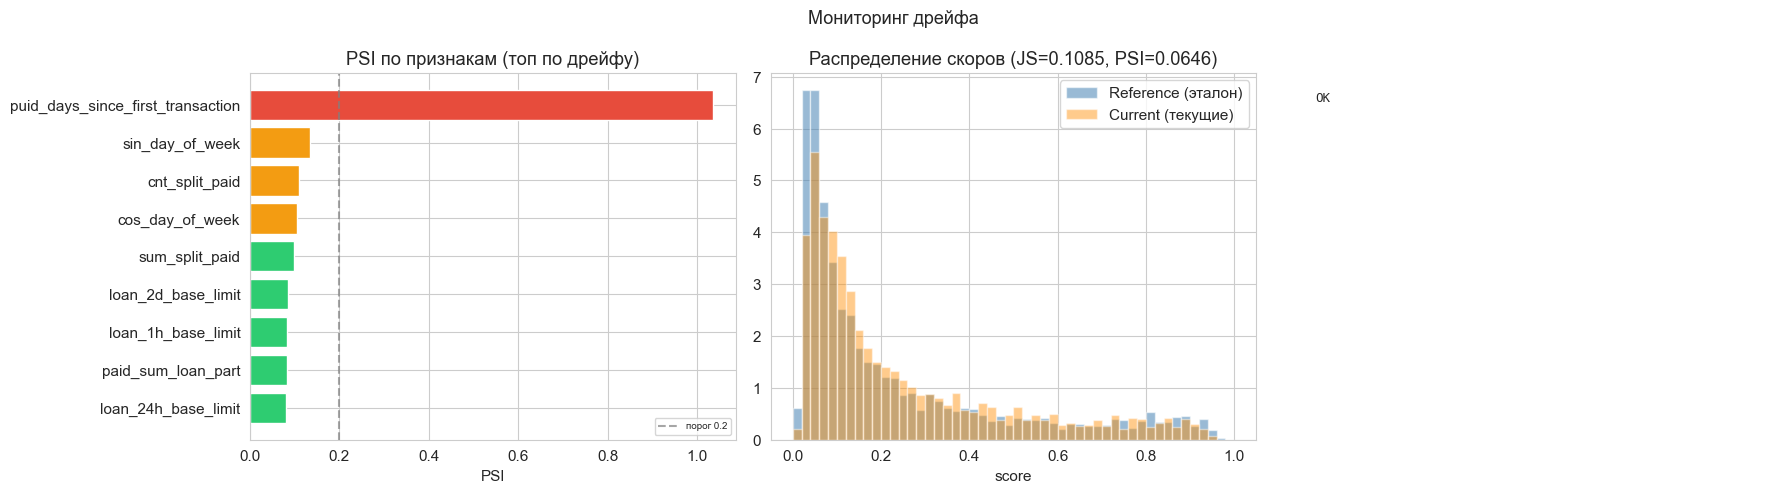

In [32]:
stage_11_drift()


## 12. Бизнес-метрики



РАЗДЕЛ 12. БИЗНЕС-МЕТРИКИ
  fraud_prevented_count: 167
  fraud_prevented_amount: 8,350,000
  fraud_missed_count: 102
  fraud_missed_amount: 5,100,000
  false_blocks_count: 492
  false_block_costs: 984,000
  review_costs: 329,500
  total_costs: 6,413,500
  net_savings: 7,036,500
  roi: 1.10


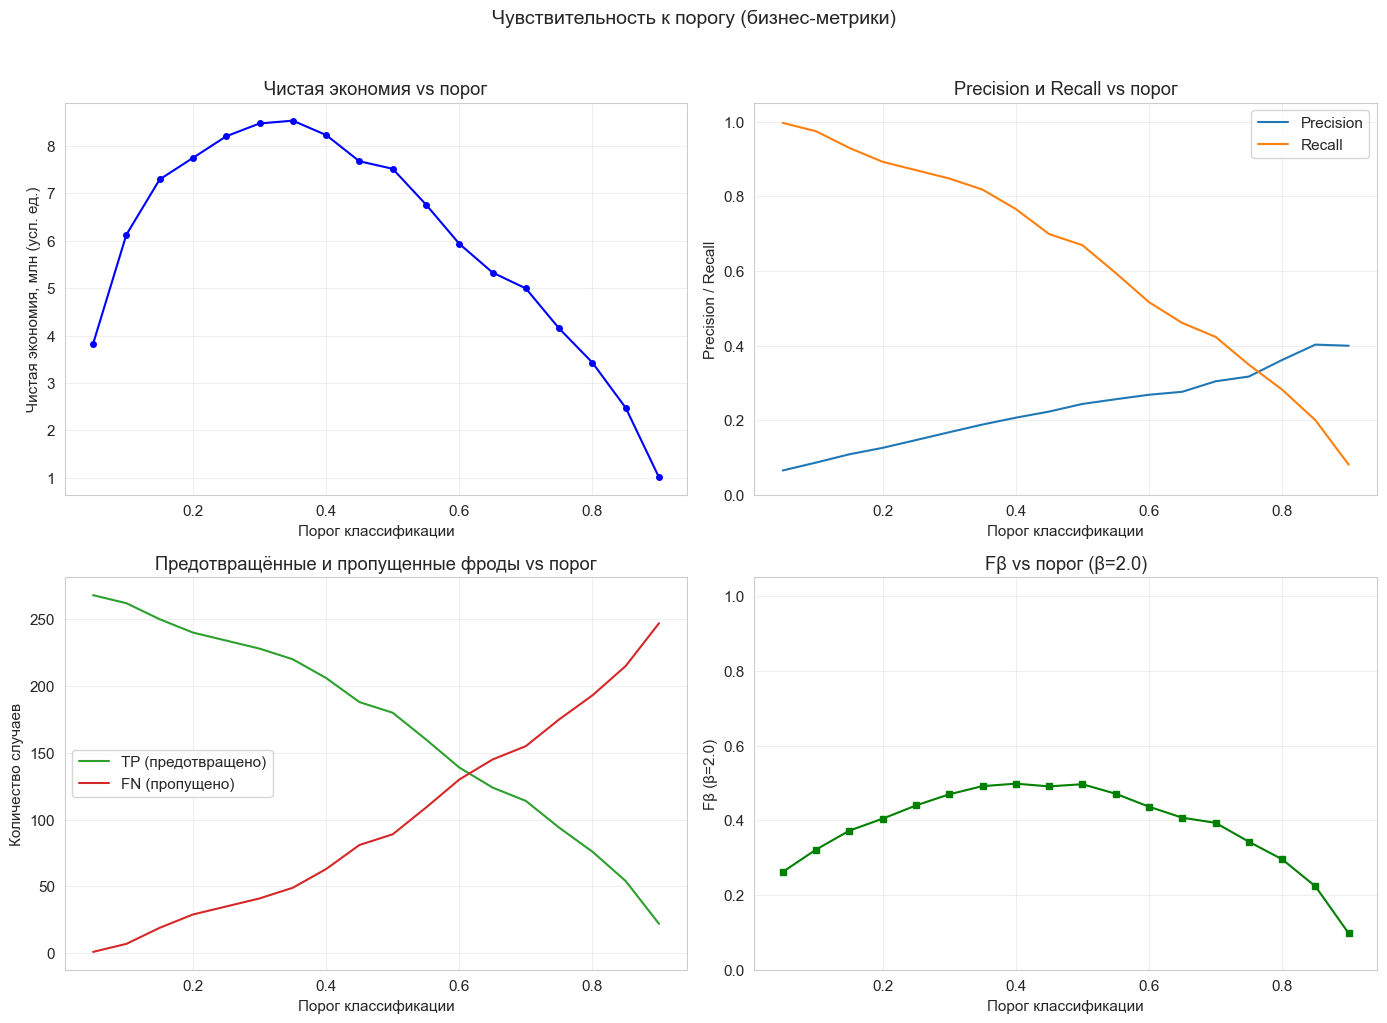

In [33]:
stage_12_business()


## 13. Калибровка



РАЗДЕЛ 13. КАЛИБРОВКА

  Калибровка XGBoost...


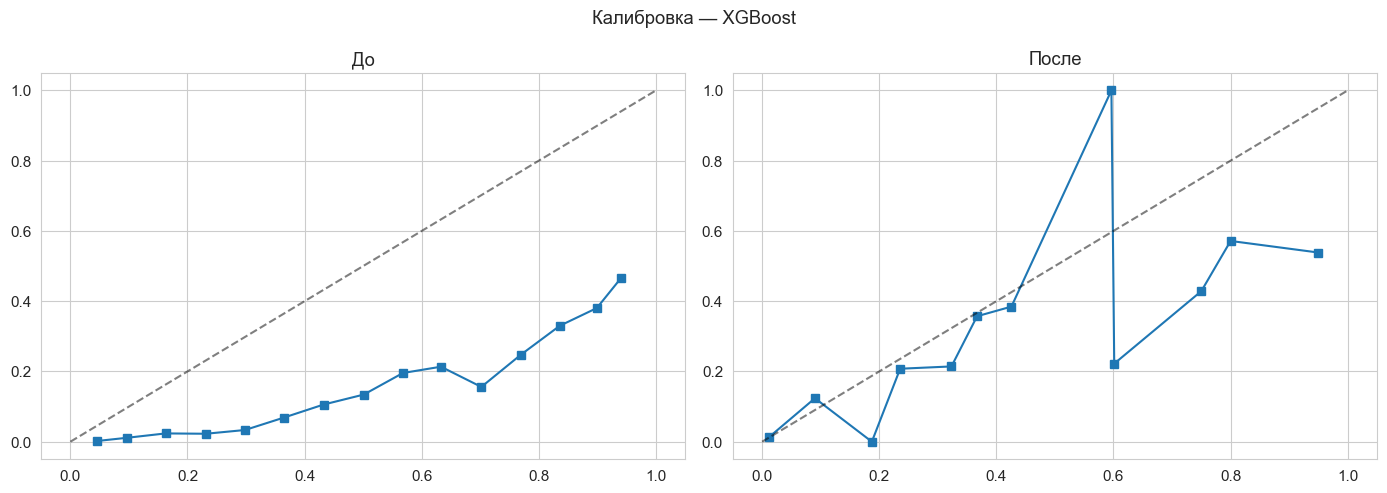

  Brier raw: 0.103658 | cal: 0.047144


In [34]:
stage_13_calibration()


## 14. Дообучение (симуляция)



РАЗДЕЛ 14. ДООБУЧЕНИЕ (симуляция)
  Champion Fβ (β=2.0): 0.4813 | Challenger: 0.4826 | Δ: +0.0013
  Дообученный XGBoost записан в P.trainer (models / predictions / results['XGBoost']).
  best_model_name — XGBoost: дальнейшие шаги с лучшей моделью видят обновлённые веса.
  Бейзлайн мониторинга дрейфа обновлён (reference = val под новым чемпионом).
  Повторная проверка (test vs новый baseline): OK


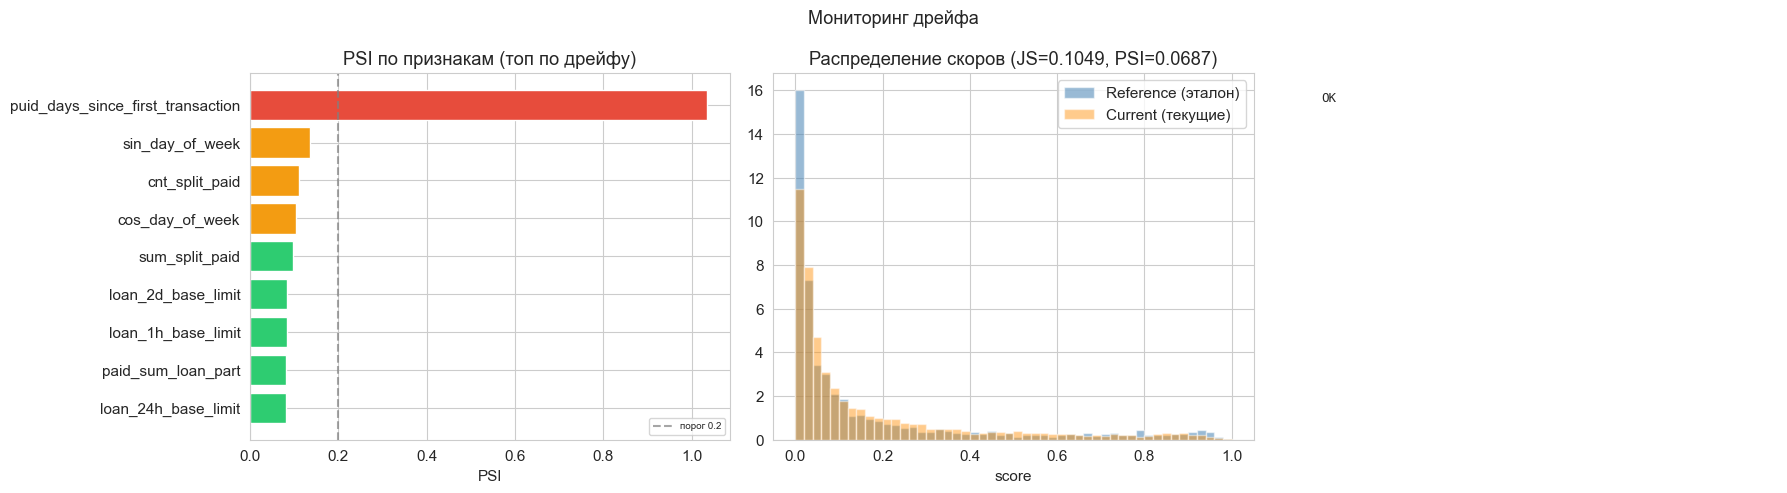

In [35]:
stage_14_retraining()


## 15. Комбинированный пайплайн


In [36]:
stage_15_combined()



РАЗДЕЛ 15. ПРАВИЛА + ML
  Combined: ML = XGBoost (Fβ=0.4826 — лучшая по Fβ на test среди доступных ML-моделей; не SHAP-only)

  Распределение решений:
    ml_block: 630 (13.43%), fraud rate: 22.8571%
    ml_pass: 3966 (84.56%), fraud rate: 2.3449%
    rule_block: 94 (2.00%), fraud rate: 34.0426%

  ROC-AUC: 0.8563 | PR-AUC: 0.2573 | Fβ (β=2.0): 0.4889 | F1: 0.3545
  Precision: 0.2431 | Recall: 0.6543 | FPR: 0.1240


## 16. Итоговый отчёт


In [37]:
stage_16_report()



РАЗДЕЛ 16. ОТЧЁТ

  --- Топ моделей по Fβ на test (β=2.0, порог с val) ---
  1. Combined_Pipeline: 0.4889
  2. XGBoost: 0.4826
  3. CatBoost: 0.4603
  4. XGBoost+SMOTE: 0.4594
  5. LightGBM: 0.4478
  6. LogReg: 0.4359

  --- Итоговая модель (лучшая по Fβ на test) ---
  Модель: Combined_Pipeline
    PR-AUC=0.2573  ROC-AUC=0.8563  Fβ=0.4889  F1=0.3545  Precision=0.2431  Recall=0.6543
    порог=0.4100  FPR=0.1240
    матрица: TP=176 FP=548 TN=3873 FN=93

  --- Модель для SHAP / калибровки / бизнес-метрик (разделы 10–13) ---
  Модель: XGBoost
    PR-AUC=0.2753  ROC-AUC=0.8551  Fβ=0.4826  F1=0.3581  Precision=0.2504  Recall=0.6283
    порог=0.4100  FPR=0.1145  LogLoss=0.2655
    матрица: TP=169 FP=506 TN=3915 FN=100

  --- Пайплайн «правила + ML» (Combined) ---
  (ML-часть: XGBoost — выбрана по Fβ в разделе 15)
  Система: Combined_Pipeline
    PR-AUC=0.2573  ROC-AUC=0.8563  Fβ=0.4889  F1=0.3545  Precision=0.2431  Recall=0.6543
    порог=0.4100  FPR=0.1240
    матрица: TP=176 FP=548 TN=3873

---
### Опционально: весь пайплайн одной ячейкой


In [38]:
# run_all_stages()